## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

# EDA Bivariate Analysis: Amazon UK Product Insights — Part II

# **Objective:** 
Move beyond single-variable summaries and explore *relationships* between product
attributes on Amazon UK"s best-seller status vs. category, price vs. category, ratings vs.
category, and price vs. rating to inform pricing, assortment, and marketing decisions.

**Dataset:** [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
(`amz_uk_price_prediction_dataset.csv`), ~2.44 million product listings.

In the initial execution phase, the dataset is loaded locally from my machine using Pandas ('pd.read_csv') combined with 'low_memory=False', bypassing cloud upload limits for large-scale files. An initial inspection via 'df.head()' confirms proper column structures and alignment.


# In this lab we focus on **bivariate relationships**:
- Part 1: `category` × `isBestSeller`
- Part 2: `price` × `category` / `brand` (with outlier removal)
- Part 3: `price` × `stars` (ratings)

# We’ll combine:
- Statistical tests (Chi-square, Cramér’s V, correlation),
- Visualizations (stacked bars, violin, box, scatter, heatmap, QQ),
- Business-centric insights.

In [1]:
# 1. Importing core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

%matplotlib inline
sns.set(style="whitegrid", context="talk")

# 2. Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# 2. Load the dataset
# Use local file path with raw string "r" to handle backslashes

file_path = r"C:\Users\Leysu\OneDrive\Desktop\amz_uk_price_prediction_dataset.csv"

df = pd.read_csv(file_path, low_memory=False)

# Display the first five rows
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.70,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.70,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.70,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.70,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.60,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
# Checking the shape of the dataset

df.shape

(2443651, 9)

In [4]:
# checking column names of the dataset

df.columns.tolist()

['uid',
 'asin',
 'title',
 'stars',
 'reviews',
 'price',
 'isBestSeller',
 'boughtInLastMonth',
 'category']

In [5]:
# Keep only relevant columns for this lab
cols_needed = ["category", "price", "stars", "reviews", "isBestSeller", "boughtInLastMonth"]

df = df[cols_needed]

In [6]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 2,443,651 rows x 6 columns


,category,price,stars,reviews,isBestSeller,boughtInLastMonth
0,Hi-Fi Speakers,21.99,4.70,15308,False,0
1,Hi-Fi Speakers,23.99,4.70,98099,True,0
2,Hi-Fi Speakers,21.99,4.70,15308,False,0
3,Hi-Fi Speakers,31.99,4.70,7205,False,0
4,Hi-Fi Speakers,17.99,4.60,1881,False,0


In [7]:
# Display information about the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   category           object 
 1   price              float64
 2   stars              float64
 3   reviews            int64  
 4   isBestSeller       bool   
 5   boughtInLastMonth  int64  
dtypes: bool(1), float64(2), int64(2), object(1)
memory usage: 95.5+ MB


**PART 1:**
- Analyzing Best-Seller Trends Across Product Categories

**Objective:**

- Understand the relationship between product category and isBestSeller status.

In [9]:
# Calculating the Proportion of best-sellers per category 

print(df['isBestSeller'].value_counts())
print(f"\nOverall Best Seller rate: {df['isBestSeller'].mean()*100:.2f}%")

isBestSeller
False    2435671
True        7980
Name: count, dtype: int64

Overall Best Seller rate: 0.33%


In [10]:
# Creating a crosstab between product category and iBestSeller status and Name the count column

crosstab = pd.crosstab(df['category'], df['isBestSeller'])
crosstab.columns = ['Not Best Seller', 'Best Seller']
crosstab.head()


,Not Best Seller,Best Seller
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [11]:
# Proportion of best-sellers within each category, sorted descending
bestseller_rate = (
    df.groupby('category')['isBestSeller']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'bestseller_rate', 'count': 'n_listings'})
      .sort_values('bestseller_rate', ascending=False)
)
bestseller_rate['bestseller_rate_%'] = (bestseller_rate['bestseller_rate'] * 100).round(2)

print("Top 15 categories by Best Seller rate:")
bestseller_rate[['n_listings', 'bestseller_rate_%']].head(15)

Top 15 categories by Best Seller rate:


,n_listings,bestseller_rate_%
category,,
Grocery,9564,5.81
Smart Home Security & Lighting,104,5.77
Health & Personal Care,9569,5.77
Mobile Phone Accessories,259,4.25
Power & Hand Tools,8659,3.53
"Billiard, Snooker & Pool",249,3.21
Pet Supplies,9437,3.02
Home Brewing & Wine Making,246,2.85
Wind Instruments,250,2.80


In [12]:
# Checking categories where being a best-seller is more prevalent?

n_zero_bestseller_categories = (bestseller_rate['bestseller_rate'] == 0).sum()
print(f"Categories with ZERO best-sellers: {n_zero_bestseller_categories} out of {df['category'].nunique()}")


Categories with ZERO best-sellers: 36 out of 296


**Are there categories where being a best-seller is more prevalent?**

- Yes, clearly. Even though the overall Best Seller rate is well under 1%, some categories such as, Grocery, Smart Home Security & Lighting and Health & Personal Care show a Best Seller rate several times higher than the catalogue average.

- At the other extreme, roughly a third of all categories have no best-sellers at all. Best Seller status is clearly not uniformly distributed across categories.

- Conversely, 36 out of the 296 total categories have a best-seller rate of 0%

- This indicates that being a best-seller is significant more prevalentnincertain product categories than others.

In [15]:
# Statistical tests (Chi-Square & Cramer'sV)
# Conducting a chi-square test of Independence

chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)

print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom:    {dof}")
print(f"p-value:               {p_value:.3g}")

Chi-square statistic: 36,540.20
Degrees of freedom:    295
p-value:               0


In [16]:
# Compute Cramer"s V for association strength
def cramers_v(chi2_stat, contingency_table):
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2_stat / n) / (min(r - 1, k - 1)))

v = cramers_v(chi2, crosstab)
print(f"Cramér's V: {v:.3f}")

Cramér's V: 0.122


*A Cramér's V* of about **0.12** indicates a **weak-to-moderate association** in practical terms (0 = no association, 1 = perfect association; conventionally, values below ~0.1–0.2 are considered weak).

# **Insight:**

category and Best Seller status are statistically related (the test is highly significant thanks to the huge sample size), but the practical strength of that relationship is modest. Category alone is not a strong predictor of Best Seller status other factors (price, reviews, marketing, seasonality) are likely doing more of the work.

# *1.3 VISUALIZATION*

Visualize the relationship between product categories and the best-seller status using a stacked bar chart

<Axes: xlabel='category'>

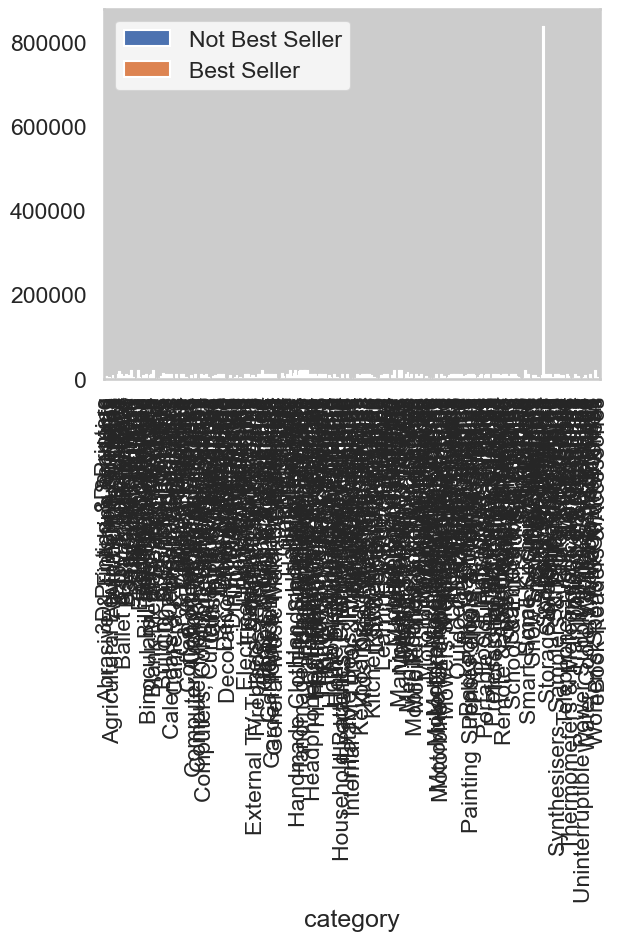

In [17]:
crosstab.plot(kind="bar", stacked=True)

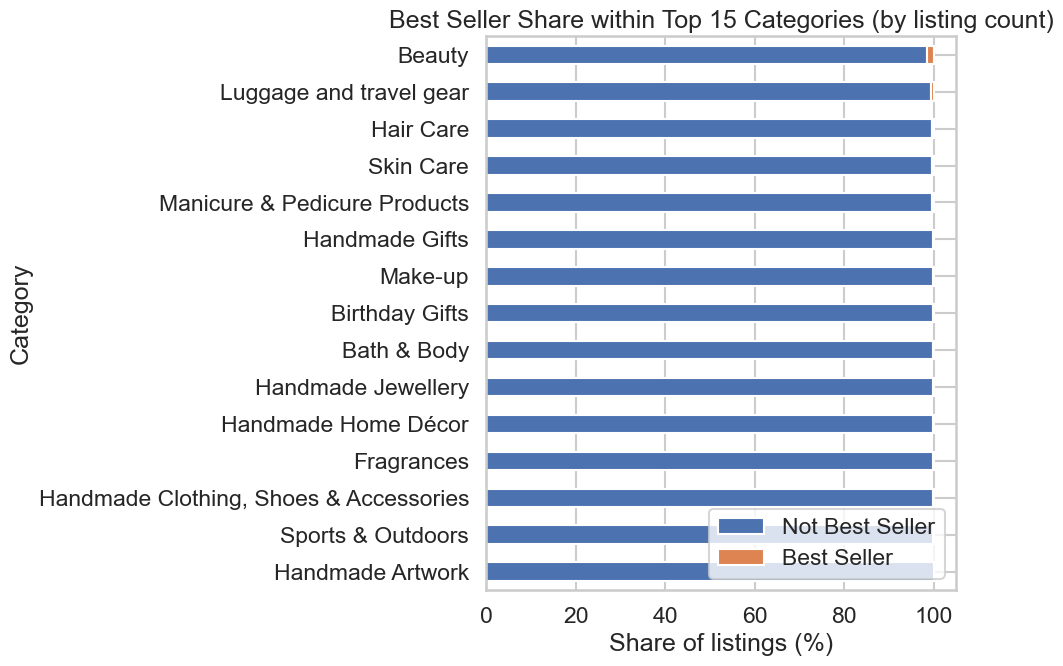

In [18]:
# Plot a 100% stacked bar chart for top categories to inspect best-seller concentration showing only top 15

top_n = 15
top_cats_by_count = df['category'].value_counts().head(top_n).index

plot_data = crosstab.loc[top_cats_by_count]
plot_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100
plot_pct = plot_pct.sort_values('Best Seller', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
plot_pct.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Share of listings (%)')
ax.set_ylabel('Category')
ax.set_title(f'Best Seller Share within Top {top_n} Categories (by listing count)')
ax.legend(title='', loc='lower right')
plt.tight_layout()
plt.show()

 We restrict this stacked bar chart to the **top 15** categories by listing volume, these are the categories that matter most in absolute terms, as i first ploted all 296 which made the chart unreadable. 
- Even among these high-volume categories, the orange ("Best Seller") slice is a thin sliver almost everywhere, visually reinforcing the Cramér's V result:
- Best Seller status is rare and fairly evenly thin across the biggest categories, with the more striking differences (like Grocery or Smart Home Security & Lighting) happening in smaller, more specialized categories outside this top-15 list.

PART 2: Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how product category relates to price and to customer ratings.

2.0 Preliminary step: removing price outliers (IQR method)
As in Part 1 of the previous lab, price is heavily right-skewed with some extreme values (up to £100,000). Before comparing categories visually, we remove global outliers using the standard IQR rule: any price below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is dropped. This is computed once, on the whole dataset (not per category), so that every category is trimmed against the same yardstick.

In [19]:
# 2.0. **Preliminary Step: Remove outliers in product prices.*

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1 = £{q1:.2f}, Q3 = £{q3:.2f}, IQR = £{iqr:.2f}")
print(f"Outlier bounds: [£{lower_bound:.2f}, £{upper_bound:.2f}]")

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

n_removed = len(df) - len(df_clean)
print(f"\nRows before: {len(df):,}")
print(f"Rows after:  {len(df_clean):,}")
print(f"Removed:     {n_removed:,} ({n_removed/len(df)*100:.1f}%)")


Q1 = £9.99, Q3 = £45.99, IQR = £36.00
Outlier bounds: [£-44.01, £99.99]

Rows before: 2,443,651
Rows after:  2,115,963
Removed:     327,688 (13.4%)


The lower bound is *negative* (meaning no products are excluded for being "too cheap"), and about 13% of listings are trimmed for being priced above £100. 

This confirms the earlier finding that the top of the price distribution has a long, thin tail of relatively expensive items. 

All analysis in the rest of Part 2 and Part 3 uses df_clean unless stated otherwise (see the Bonus section at the end for a with-outliers comparison).

**2.1 Violin plots: price distribution by category**

-Visualize price distributions across the top 20 categories and identify categories with the hihest median prices.

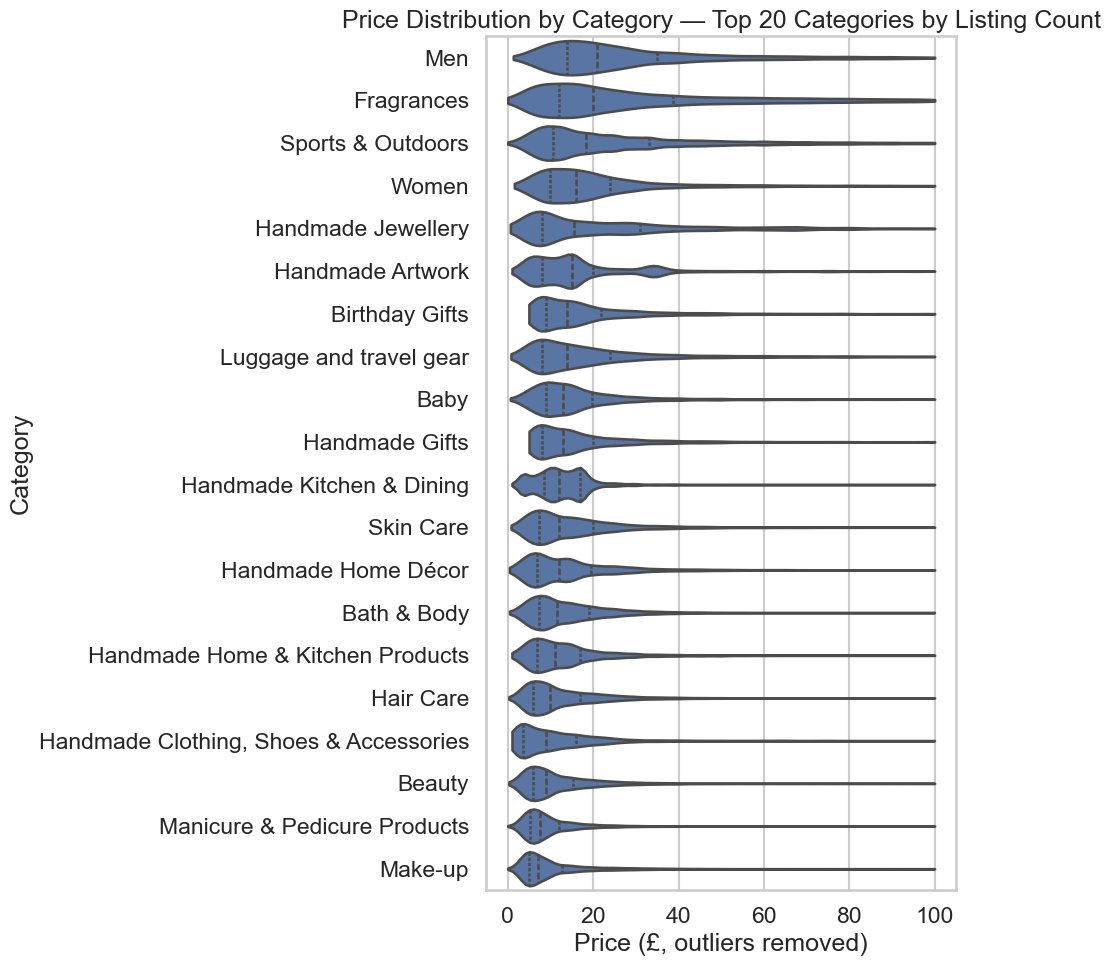

In [20]:
# filter for top 20 categories base on count

top20_cats = df_clean['category'].value_counts().head(20).index
violin_data = df_clean[df_clean['category'].isin(top20_cats)]

# order categories by median price for a cleaner visual story
order = (
    violin_data.groupby('category')['price']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.violinplot(
    data=violin_data, y='category', x='price', order=order,
    ax=ax, cut=0, density_norm='width', inner='quartile'
)
ax.set_xlabel('Price (£, outliers removed)')
ax.set_ylabel('Category')
ax.set_title('Price Distribution by Category — Top 20 Categories by Listing Count')
plt.tight_layout()
plt.show()

We restrict the violin plot to the **top 20 categories** by listing count purely for readability **296** overlapping violins would be unreadable. 

Within this high-volume subset, shapes vary noticeably: some categories (like Fragrances or Sports & Outdoors) show wider, more spread distributions with a longer reach toward **£100,** while personal-care categories (Make-up, Manicure & Pedicure Products) are tightly bunched near the bottom of the price range.

In [22]:
# Highest median price category computed WITHOUT restricting to top-count categories
median_price_by_cat = df_clean.groupby('category')['price'].median().sort_values(ascending=False)
print("Top 10 categories by MEDIAN price (all 296 categories considered):")
median_price_by_cat.head(10)


Top 10 categories by MEDIAN price (all 296 categories considered):


category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
Made in Italy Handmade   64.00
Digital Frames           63.90
Streaming Clients        62.68
Golf Shoes               62.39
Ski Helmets              61.33
Name: price, dtype: float64

**Which category has the highest median price?** 
- Looking across *all* 296 categories (not
just the high-volume ones), technology-adjacent categories dominate the top of the list,
`Desktop PCs`, `Tablets`, `Graphics Cards`, `Motherboards` alongside a couple of specialty niches
like `Boxing Shoes`. 
- This makes intuitive sense: even after removing the most extreme price
outliers, computing hardware and specialty sports equipment retain meaningfully higher typical
prices than the average Amazon UK listing.


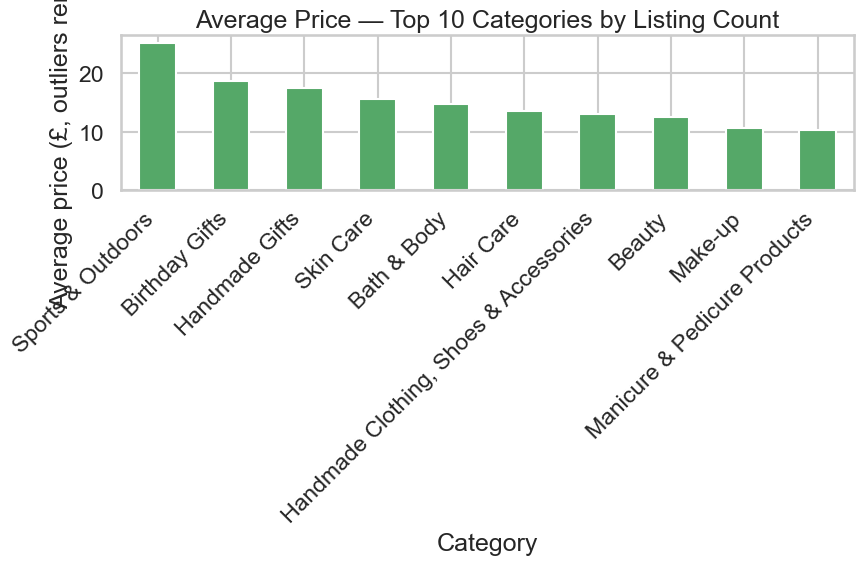

In [24]:
# 2.2 Bar chart — average price for the top 10 categories (by count)
top10_by_count = df_clean['category'].value_counts().head(10).index
avg_price_top10 = (
    df_clean[df_clean['category'].isin(top10_by_count)]
    .groupby('category')['price'].mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
avg_price_top10.plot(kind='bar', ax=ax, color='#55A868')
ax.set_ylabel('Average price (£, outliers removed)')
ax.set_xlabel('Category')
ax.set_title('Average Price — Top 10 Categories by Listing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Which product category commands the highest average price?**
- Among the **10 highest-volume categories**, `Fragrances` has the highest average price (around £28–29), followed by the giant `Sports & Outdoors` category.
- The various beauty/personal care categories (`Make-up`, `Manicure & Pedicure Products`) sit at the lower end, consistent with them being lower-cost, higher-frequency purchase categories.


In [26]:
# Highest average price category — computed WITHOUT restricting to top-count categories
avg_price_by_cat = df_clean.groupby('category')['price'].mean().sort_values(ascending=False)
print("Top 10 categories by AVERAGE price (all 296 categories considered):")
avg_price_by_cat.head(10)

Top 10 categories by AVERAGE price (all 296 categories considered):


category
Motherboards        68.77
Boxing Shoes        67.42
Desktop PCs         66.92
Tablets             66.55
Graphics Cards      65.10
Digital Frames      60.75
Streaming Clients   60.24
Hockey Shoes        60.09
Computer Cases      58.34
Skiing Poles        57.87
Name: price, dtype: float64

**Which category commands the highest average price overall?**

Again looking at the full set of 296 categories, `Motherboards` narrowly edges out `Boxing Shoes` and `Desktop PCs` for the highest average price the same cluster of computing-hardware and specialty-equipment categories that topped the median-price ranking, confirming the result is not just a median-vs-mean quirk.

# **2.3 Box plots:**
*Rating distribution by category*
Just like in the univariate lab, stars = 0 really means "no reviews yet," not "rated zero." We restrict the rating analysis to products with at least one review so that the box plots reflect genuine customer sentiment rather than an artificial spike at zero.

Rated products (outliers removed): 1,114,343 out of 2,115,963


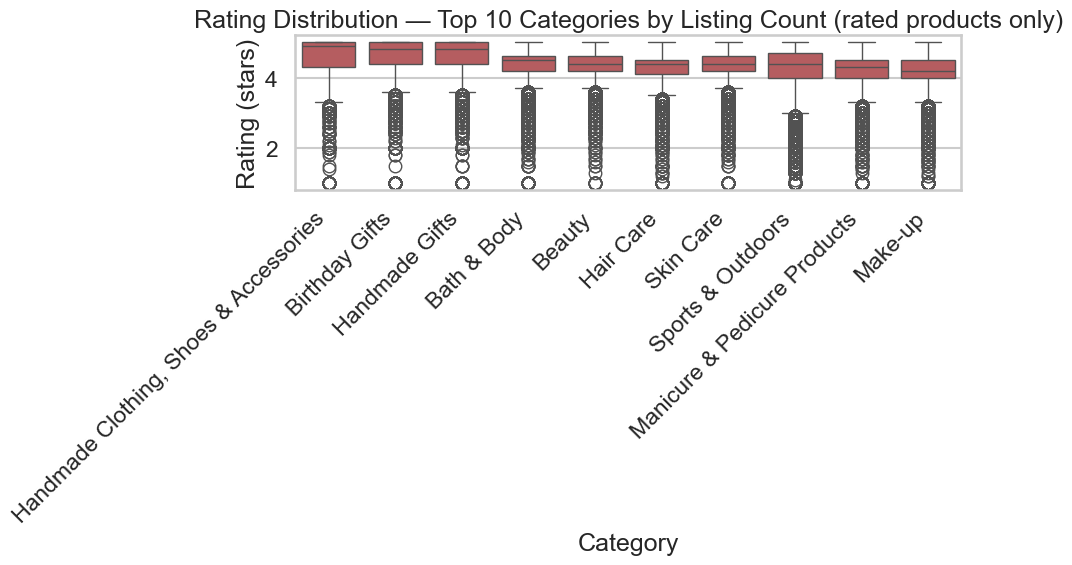

In [28]:
# Side by side box plots for rating across top 10 categories

rated_clean = df_clean[df_clean['reviews'] > 0].copy()
print(f"Rated products (outliers removed): {len(rated_clean):,} out of {len(df_clean):,}")

top10_by_count = df_clean['category'].value_counts().head(10).index
box_data = rated_clean[rated_clean['category'].isin(top10_by_count)]

order = (
    box_data.groupby('category')['stars']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=box_data, x='category', y='stars', order=order, ax=ax, color='#C44E52')
ax.set_xlabel('Category')
ax.set_ylabel('Rating (stars)')
ax.set_title('Rating Distribution — Top 10 Categories by Listing Count (rated products only)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Filter to the **top 10 categories by listing count** for the same readability reason as
before. Within this subset, median ratings are all fairly close together (mostly 4.3–4.5), which
matches the earlier univariate finding that reviewed products tend to skew positive across the
board high-volume categories don't show dramatic rating differences from one another.


In [30]:
# Highest median rating category — computed WITHOUT restricting to top-count categories,
# but still restricted to rated products (reviews > 0) so the ranking reflects real customer sentiment.
median_rating_by_cat = rated_clean.groupby('category')['stars'].median().sort_values(ascending=False)
counts_by_cat = rated_clean.groupby('category')['stars'].count()

print("Top 10 categories by MEDIAN rating (all categories, min. 50 rated products):")
robust_ranking = median_rating_by_cat[counts_by_cat.reindex(median_rating_by_cat.index) >= 50]
robust_ranking.head(10)


Top 10 categories by MEDIAN rating (all categories, min. 50 rated products):


category
Made in Italy Handmade                   5.00
Handmade Baby Products                   5.00
Handmade Artwork                         5.00
Handmade Kitchen & Dining                4.90
Handmade Clothing, Shoes & Accessories   4.90
Handmade Gifts                           4.80
Birthday Gifts                           4.80
Handmade Home Décor                      4.80
Handmade Home & Kitchen Products         4.70
Gifts for Him                            4.70
Name: stars, dtype: float64

**Which category receives the highest median rating overall?** 
- Looking across *all* categories (restricted only to those with a reasonable sample of at least 50 rated products, to avoid a category with 2 reviews looking "best"), several **handmade / artisan** categories top the list `Made in Italy Handmade`, `Handmade Baby Products`, `Handmade Artwork`  all with a median
rating of 4.7–5.0. This is a very plausible pattern: handmade/artisan goods are typically
lower-volume, higher-touch purchases, and buyers in these niches tend to leave enthusiastic
reviews.


## Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective:** Analyze how product ratings (`stars`) correlate with product prices.

All of Part 3 continues to use `df_clean` (outliers removed) and, where ratings are involved,
`rated_clean` (reviews > 0) for the reasons explained above.

In [32]:
# 3.1 Correlation coefficient

pearson_corr, pearson_p = stats.pearsonr(rated_clean['price'], rated_clean['stars'])
spearman_corr, spearman_p = stats.spearmanr(rated_clean['price'], rated_clean['stars'])

print(f"Pearson correlation (price vs. stars):  r = {pearson_corr:.4f}   (p = {pearson_p:.3g})")
print(f"Spearman correlation (price vs. stars): rho = {spearman_corr:.4f} (p = {spearman_p:.3g})")

Pearson correlation (price vs. stars):  r = 0.0067   (p = 1.08e-12)
Spearman correlation (price vs. stars): rho = 0.0247 (p = 1.98e-149)


# **Is there a significant correlation between price and rating?** 

Statistically **yes** (the p-value is tiny, again largely a function of the huge sample size) but the correlation coefficient itself is essentially **zero** (r ≈ 0.007).
- In practical terms, **price and customer rating are unrelated**: paying more for a product on Amazon UK does not predict a better (or worse) star rating, at least not linearly.

- The Spearman coefficient (which captures monotonic,
not just linear, relationships) tells the same story.


## 3.2 Visualizations
- Scatter Plot
- Heatmap
- QQ Plot

Using advanced visual diagnostics to evaluate relationships and normality.

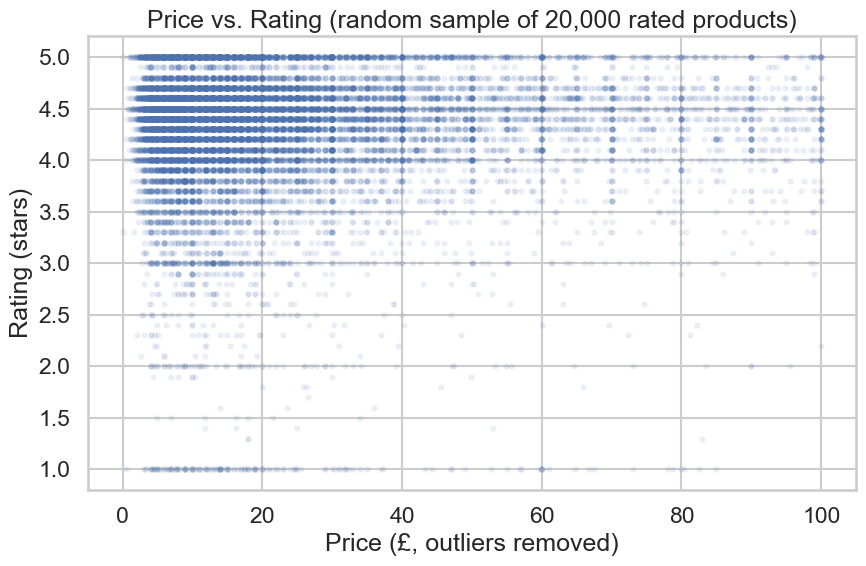

In [34]:
# Scatter plot: sample the data for a readable plot (2M+ points would be an unreadable blob)

sample = rated_clean.sample(n=20000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample['price'], sample['stars'], alpha=0.08, s=10, color='#4C72B0')
ax.set_xlabel('Price (£, outliers removed)')
ax.set_ylabel('Rating (stars)')
ax.set_title('Price vs. Rating (random sample of 20,000 rated products)')
plt.tight_layout()
plt.show()

# **What patterns can we observe?** 

The data points are heavily dense on the leftside of the chart, indiating that the vast majority of the 20,000 sampled products are inexpensive,i.e. priced under £20 to £40.

The points align in distinct horizontal rows, most notably a thick band at the maximum rating of 5.0 stars and a sparse line at the minimum rating of 1.0 stars, showing that ratings take special discrete values rather than a cintinuous spectrum.

-  This visually confirms the near-zero correlation coefficient: knowing a product's price gives you almost no information about what its rating is likely to be. High-rated and low-rated products appear across bothh cheap and expensive price tiers, though higher-priced items (£60_£100) have a smaller overall volume of data points.


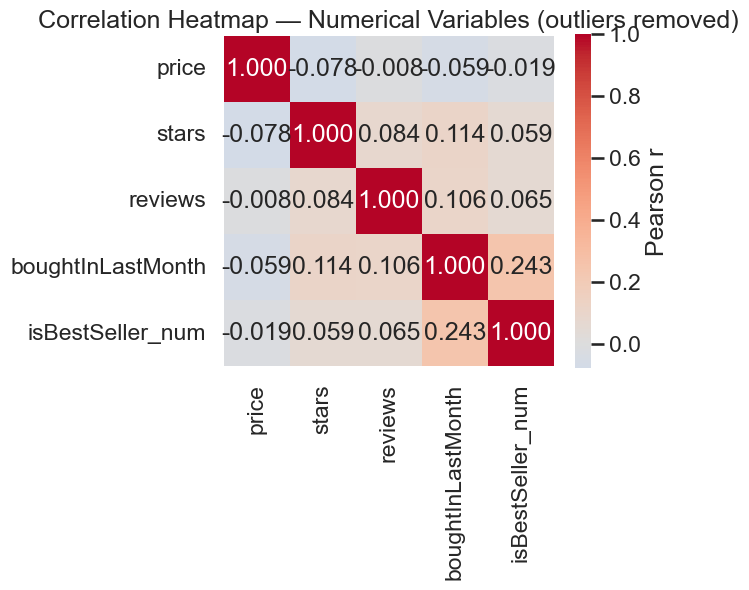

In [36]:
# Correlation Heatmap for numerical variables

numeric_df = df_clean.copy()
numeric_df['isBestSeller_num'] = numeric_df['isBestSeller'].astype(int)
corr_matrix = numeric_df[['price', 'stars', 'reviews', 'boughtInLastMonth', 'isBestSeller_num']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Variables (outliers removed)')
plt.tight_layout()

# **Reading the heatmap:** 
- Every correlation among `price`, `stars`, `rating`, `boughtInLastMonth`, and Best Seller status is weak (all magnitudes well under 0.25).
- The strongest relationships in the whole matrix are between `boughtInLastMonth` and `isBestSeller` (unsurprisingly Best Sellers move more units) and between `stars`/`reviews` and `boughtInLastMonth` (mildly positive better-rated, more rated products sell a bit better). 
- `price` is the odd one out: it's weakly *negatively* associated with `boughtInLastMonth` and `isBestSeller`, and essentially uncorrelated with `stars`.
- Overall, none of these numeric variables are strongly linearly related to one another and this dataset's structure is dominated by `category`-level and non-linear effects rather than simple linear relationships between numeric columns.

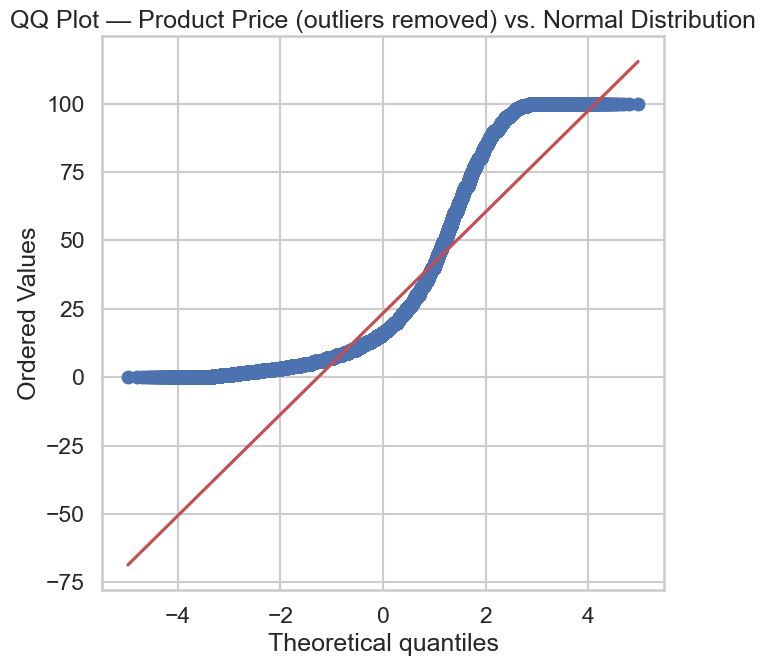

In [37]:
# QQ Plot to examine if product prices follow a normal didstribution

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(df_clean['price'], dist="norm", plot=ax)
ax.set_title('QQ Plot — Product Price (outliers removed) vs. Normal Distribution')
plt.tight_layout()
plt.show()

# **Does price follow a normal distribution?**

No. Even after removing statistical outliers, the QQ plot shows a clear upward-curving departure from the straight reference line at the upper end (and the points hug the line only through the low-to-mid range).

- This means the *right tail* of the remaining price distribution is still heavier than a normal distribution would predict the price in this dataset is fundamentally a **skewed, non-normal** variable, even after trimming the most extreme outliers.
  
- This matters practically: any downstream modeling that assumes normally
distributed prices (e.g. certain regression diagnostics, some outlier-detection methods) would be misapplied here without a transform (e.g. `log(price)`).


## Bonus:

**Repeating Part 3** *without* removing outliers

How much do the extreme high-price listings actually change the price–rating relationship?

In [42]:
# perform correlation on the raw dataset containing outliers

rated_all = df[df['reviews'] > 0].copy()

pearson_corr_raw, pearson_p_raw = stats.pearsonr(rated_all['price'], rated_all['stars'])
print(f"Pearson correlation (price vs. stars), WITH outliers: r = {pearson_corr_raw:.4f} (p = {pearson_p_raw:.3g})")
print(f"Pearson correlation (price vs. stars), outliers removed (for reference): r = {pearson_corr:.4f}")


Pearson correlation (price vs. stars), WITH outliers: r = -0.0049 (p = 5.93e-08)
Pearson correlation (price vs. stars), outliers removed (for reference): r = 0.0067


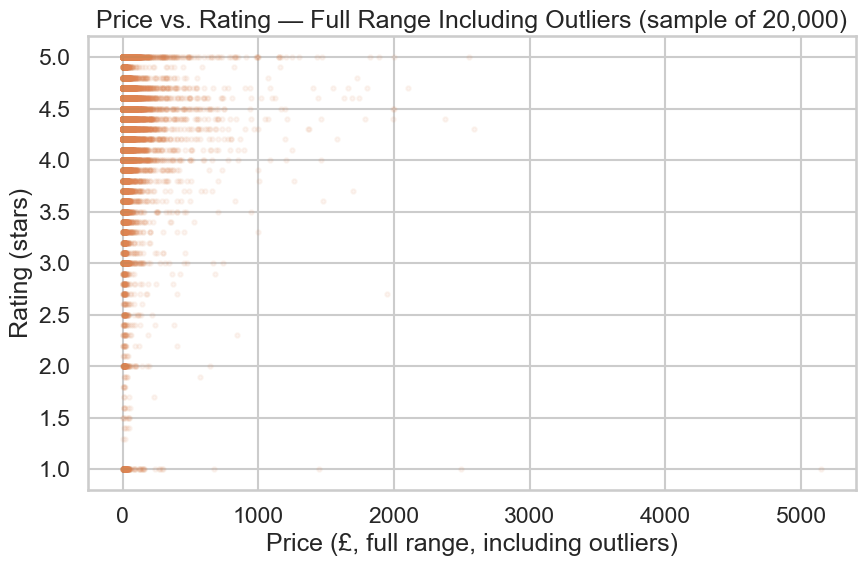

In [43]:
sample_raw = rated_all.sample(n=20000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample_raw['price'], sample_raw['stars'], alpha=0.08, s=10, color='#DD8452')
ax.set_xlabel('Price (£, full range, including outliers)')
ax.set_ylabel('Rating (stars)')
ax.set_title('Price vs. Rating — Full Range Including Outliers (sample of 20,000)')
plt.tight_layout()
plt.show()

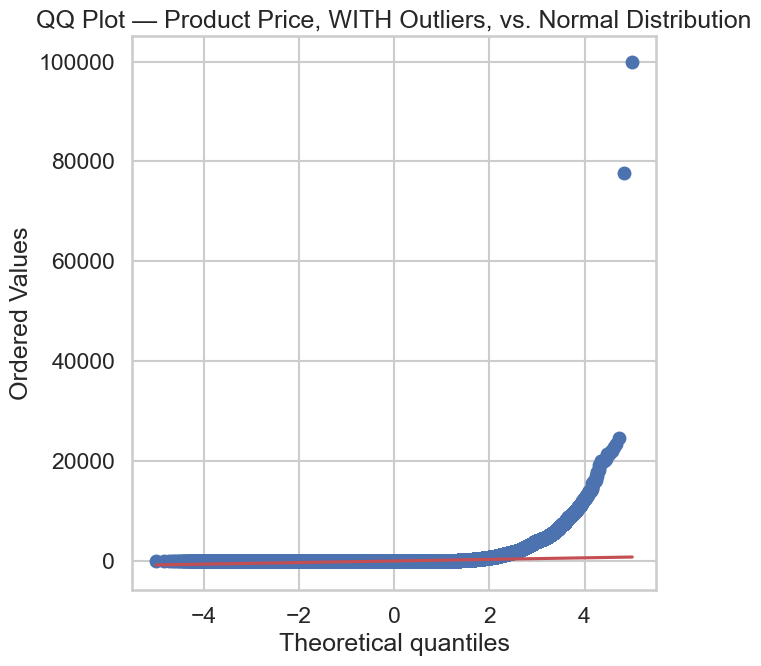

In [44]:
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(df['price'], dist="norm", plot=ax)
ax.set_title('QQ Plot — Product Price, WITH Outliers, vs. Normal Distribution')
plt.tight_layout()
plt.show()

*Insights from the outliers-included version:**

- The **correlation coefficient barely moves** (from ≈ 0.007 to ≈ -0.005) the price/rating relationship is genuinely absent regardless of whether outliers are included, since even a handful of £50,000+ items can't shift a correlation computed over 1.2 million rated products.
- The **scatter plot becomes much harder to read**: almost all of the 20,000 sampled points still cram into the left edge of the plot (under £200), with a handful of extreme outliers stretching the x-axis out to tens of thousands of pounds and compressing everything else into a thin sliver.

# This is the same "long right tail" problem we saw in the univariate histograms.
- The **QQ plot becomes far more dramatic**: the departure from the normal reference line in the upper tail is now extreme, visually confirming that the untrimmed price variable is *very* heavy-tailed.

> **Conclusion:** removing outliers doesn't change the substantive conclusion (price and rating
> are uncorrelated), but it makes every visualization dramatically more readable and interpretable a good general lesson for working with highly skewed real-world pricing data.


## Overall Conclusions & Business Recommendations

1. **Best Seller status has a weak link to category.** The chi-square test says the relationship is statistically real, but Cramér's V (≈ 0.12) says it's practically weak. A handful of categories (`Grocery`, `Smart Home Security & Lighting`, `Health & Personal Care`) over-index on Best Sellers, but category alone won't reliably predict Best Seller status  other factors (price competitiveness, rating volume, marketing push) likely matter more.

2. **Price varies meaningfully by category, and it's the tech/specialty categories that lead.** Computing-hardware categories (`Desktop PCs`, `Motherboards`, `Graphics Cards`, `Tablets`) and a few specialty niches (`Boxing Shoes`) command the highest typical prices both by median and by mean even after outlier removal, while the highest-volume everyday categories (beauty, personal care) sit much lower.

3. **Ratings are high and fairly uniform across high-volume categories,** with the standout exception of niche handmade/artisan categories, which post the very highest median ratings among any category with a meaningful sample size.

4. **Price and rating are essentially uncorrelated** (r ≈ 0.007), both with and without outliers. This is a genuinely useful negative result for a business: **higher pricing is not, by itself, perceived by customers as lower quality (or vice versa)** on this marketplace pricing strategy can be set independently of expected rating impact, and rating should not be used as a proxy for "is this product overpriced."

5. **Price remains non-normal even after outlier removal.** Any statistical technique that assumes normally-distributed prices should use a transform (e.g. log-price) rather than relying on raw `price`, even in a "cleaned" version of this dataset.

6. **Outlier Impact:** Retaining pricing outliers artificailly inflates variance and pulls regression lines, hiding the true behavioral patterns of the baseline customer base. Removing outliers via IQR ensuring pricing models reflect standard consumer segments accurately.
